In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/shopping_behavior_updated.csv')
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Shape: (3900, 18)
Columns: ['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category', 'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season', 'Review Rating', 'Subscription Status', 'Shipping Type', 'Discount Applied', 'Promo Code Used', 'Previous Purchases', 'Payment Method', 'Frequency of Purchases']


In [35]:
# Check first 5 rows — see what the data looks like
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [36]:
# Check for missing values and duplicates
print("Missing values in each column:")
print(df.isnull().sum())

print("\nTotal duplicate Customer IDs:", df.duplicated('Customer ID').sum())

Missing values in each column:
Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

Total duplicate Customer IDs: 0


In [37]:
# Standardize column names for SQL compatibility
df.columns = df.columns.str.replace(' ', '_').str.lower()
df.rename(columns={'purchase_amount_(usd)': 'purchase_amount'}, inplace=True)

print("Updated column names:")
print(df.columns.tolist())

Updated column names:
['customer_id', 'age', 'gender', 'item_purchased', 'category', 'purchase_amount', 'location', 'size', 'color', 'season', 'review_rating', 'subscription_status', 'shipping_type', 'discount_applied', 'promo_code_used', 'previous_purchases', 'payment_method', 'frequency_of_purchases']


In [38]:
# Basic statistics — understand the numbers
print("Total Customers:", len(df))
print("Total Revenue: $", df['purchase_amount'].sum())
print("Average Order Value: $", round(df['purchase_amount'].mean(), 2))
print("Age Range:", df['age'].min(), "to", df['age'].max())
print("\nCategories:", df['category'].unique())

Total Customers: 3900
Total Revenue: $ 233081
Average Order Value: $ 59.76
Age Range: 18 to 70

Categories: <ArrowStringArray>
['Clothing', 'Footwear', 'Outerwear', 'Accessories']
Length: 4, dtype: str


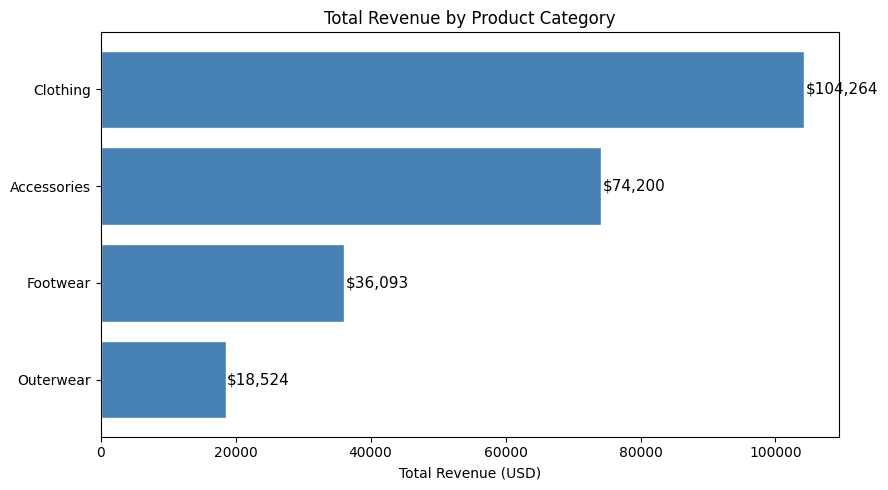

In [39]:
# CHART 1 — Revenue by Product Category
category_revenue = df.groupby('category')['purchase_amount'].sum().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(category_revenue.index, category_revenue.values,
               color='steelblue', edgecolor='white')

for bar, val in zip(bars, category_revenue.values):
    ax.text(bar.get_width() + 200,
            bar.get_y() + bar.get_height()/2,
            f'${val:,.0f}', va='center', fontsize=11)

ax.set_title('Total Revenue by Product Category')
ax.set_xlabel('Total Revenue (USD)')
plt.tight_layout()
plt.show()

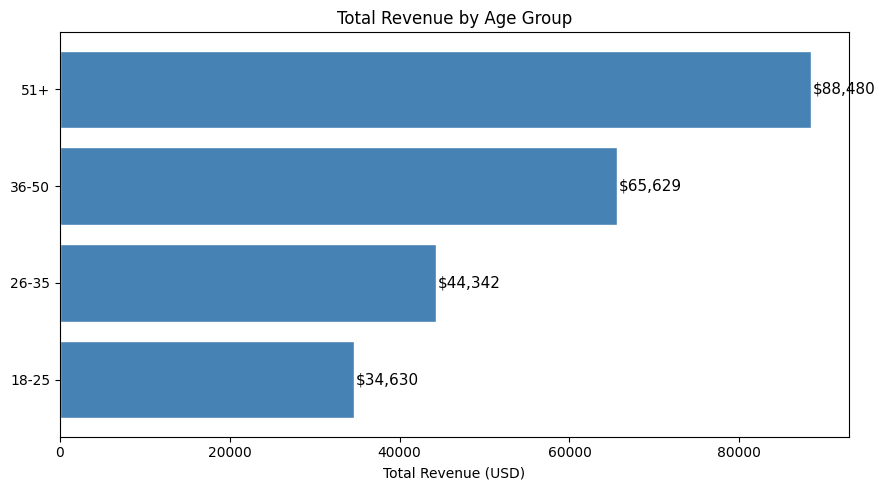

In [40]:
# CHART 2 — Revenue by Age Group
df['age_group'] = pd.cut(df['age'],
                          bins=[17, 25, 35, 50, 70],
                          labels=['18-25', '26-35', '36-50', '51+'])

age_revenue = df.groupby('age_group', observed=True)['purchase_amount'].sum().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(age_revenue.index.astype(str), age_revenue.values,
               color='steelblue', edgecolor='white')

for bar, val in zip(bars, age_revenue.values):
    ax.text(bar.get_width() + 200,
            bar.get_y() + bar.get_height()/2,
            f'${val:,.0f}', va='center', fontsize=11)

ax.set_title('Total Revenue by Age Group')
ax.set_xlabel('Total Revenue (USD)')
plt.tight_layout()
plt.show()

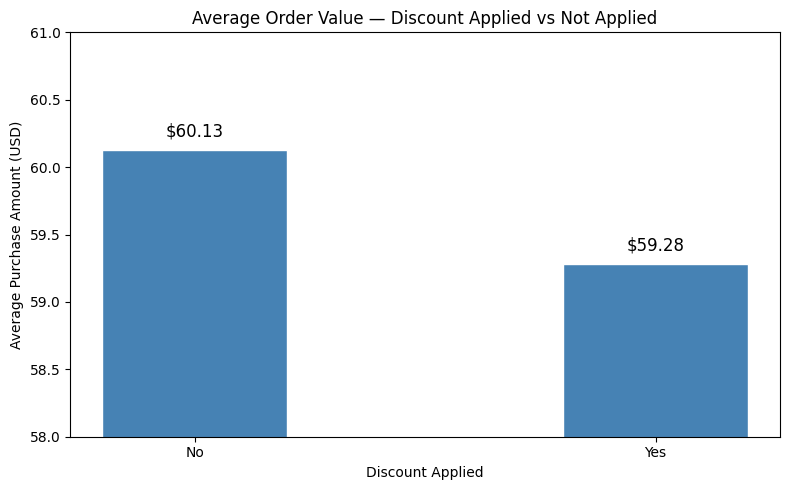

In [41]:
# CHART 3 — Discount Impact on Average Order Value
discount_avg = df.groupby('discount_applied')['purchase_amount'].mean()

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(discount_avg.index, discount_avg.values,
              color='steelblue', edgecolor='white', width=0.4)

for bar, val in zip(bars, discount_avg.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.1,
            f'${val:.2f}', ha='center', fontsize=12)

ax.set_title('Average Order Value — Discount Applied vs Not Applied')
ax.set_xlabel('Discount Applied')
ax.set_ylabel('Average Purchase Amount (USD)')
ax.set_ylim(58, 61)
plt.tight_layout()
plt.show()

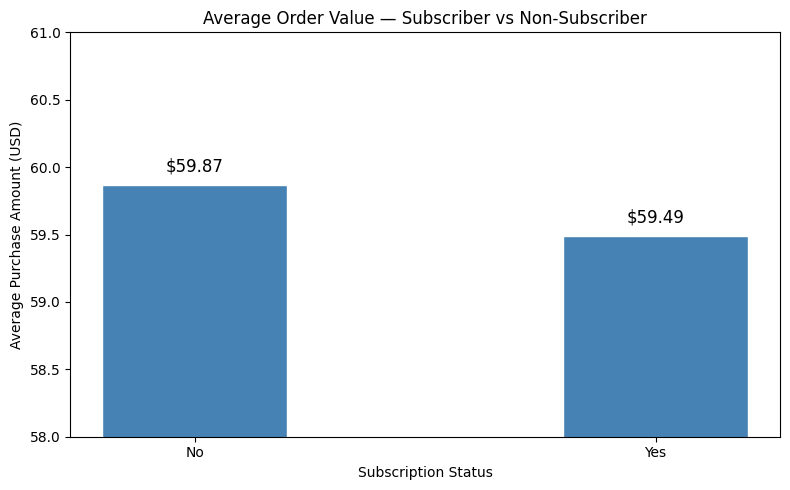

In [42]:
# CHART 4 — Do subscribers spend more?
sub_avg = df.groupby('subscription_status')['purchase_amount'].mean()

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(sub_avg.index, sub_avg.values,
              color='steelblue', edgecolor='white', width=0.4)

for bar, val in zip(bars, sub_avg.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.1,
            f'${val:.2f}', ha='center', fontsize=12)

ax.set_title('Average Order Value — Subscriber vs Non-Subscriber')
ax.set_xlabel('Subscription Status')
ax.set_ylabel('Average Purchase Amount (USD)')
ax.set_ylim(58, 61)
plt.tight_layout()
plt.show()

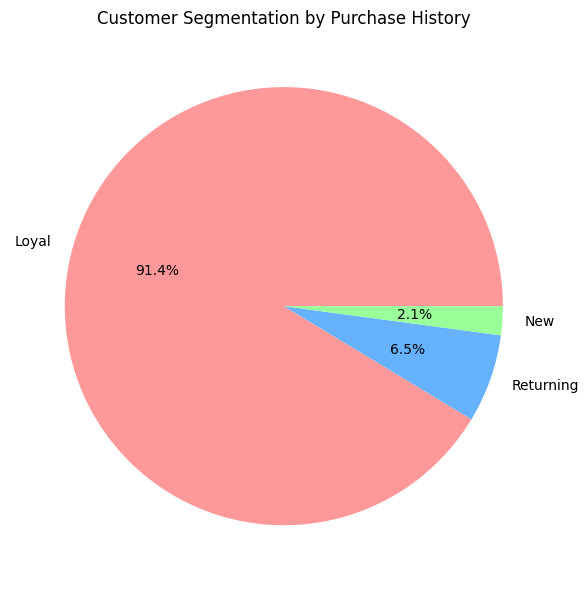

In [43]:
# CHART 5 — Customer Segmentation
df['customer_segment'] = pd.cut(
    df['previous_purchases'],
    bins=[-1, 1, 4, float('inf')],
    labels=['New', 'Returning', 'Loyal']
)
segment_counts = df['customer_segment'].value_counts()

fig, ax = plt.subplots(figsize=(8, 6))
ax.pie(segment_counts.values,
       labels=segment_counts.index,
       autopct='%1.1f%%',
       colors=['#FF9999', '#66B2FF', '#99FF99'])
ax.set_title('Customer Segmentation by Purchase History')
plt.tight_layout()
plt.show()

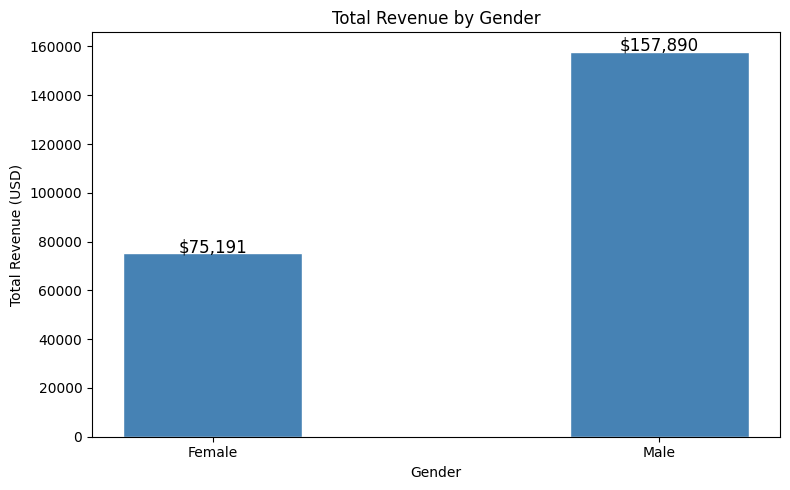

In [44]:
# CHART 6 — Revenue by Gender
gender_data = df.groupby('gender').agg(
    total_revenue=('purchase_amount', 'sum'),
    customer_count=('purchase_amount', 'count'),
    avg_spend=('purchase_amount', 'mean')
).round(2)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(gender_data.index, gender_data['total_revenue'],
              color='steelblue', edgecolor='white', width=0.4)
for bar, val in zip(bars, gender_data['total_revenue']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 500,
            f'${val:,.0f}', ha='center', fontsize=12)
ax.set_title('Total Revenue by Gender')
ax.set_xlabel('Gender')
ax.set_ylabel('Total Revenue (USD)')
plt.tight_layout()
plt.show()

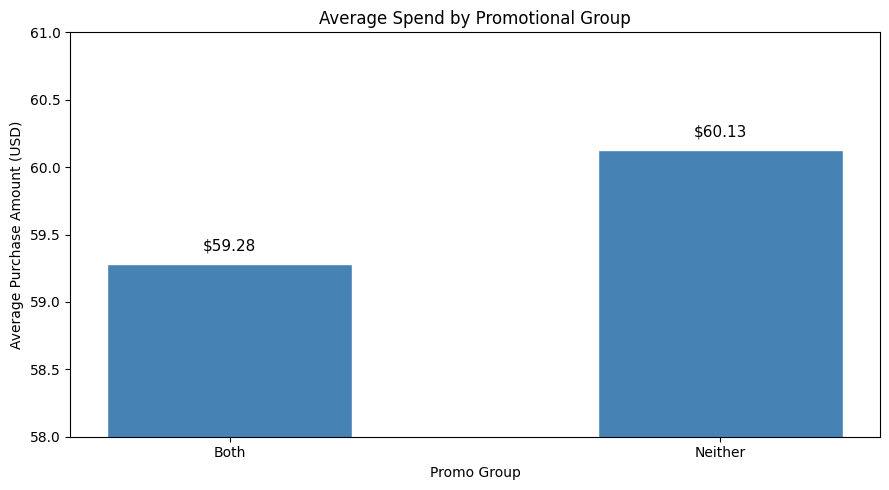

In [45]:
# CHART 7 — Promo Code vs Discount (4 group comparison)
df['promo_group'] = 'Neither'
df.loc[(df['discount_applied']=='Yes') & 
       (df['promo_code_used']=='Yes'), 'promo_group'] = 'Both'
df.loc[(df['discount_applied']=='No') & 
       (df['promo_code_used']=='Yes'), 'promo_group'] = 'Promo Only'
df.loc[(df['discount_applied']=='Yes') & 
       (df['promo_code_used']=='No'), 'promo_group'] = 'Discount Only'

promo_avg = df.groupby('promo_group')['purchase_amount'].mean().sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(promo_avg.index, promo_avg.values,
              color='steelblue', edgecolor='white', width=0.5)
for bar, val in zip(bars, promo_avg.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.1,
            f'${val:.2f}', ha='center', fontsize=11)
ax.set_title('Average Spend by Promotional Group')
ax.set_xlabel('Promo Group')
ax.set_ylabel('Average Purchase Amount (USD)')
ax.set_ylim(58, 61)
plt.tight_layout()
plt.show()

In [46]:
# Save cleaned CSV with proper column names for MySQL
df.to_csv('../data/cleaned_shopping_data.csv', index=False)
print("Saved! Columns are:")
print(df.columns.tolist())

Saved! Columns are:
['customer_id', 'age', 'gender', 'item_purchased', 'category', 'purchase_amount', 'location', 'size', 'color', 'season', 'review_rating', 'subscription_status', 'shipping_type', 'discount_applied', 'promo_code_used', 'previous_purchases', 'payment_method', 'frequency_of_purchases', 'age_group', 'customer_segment', 'promo_group']
